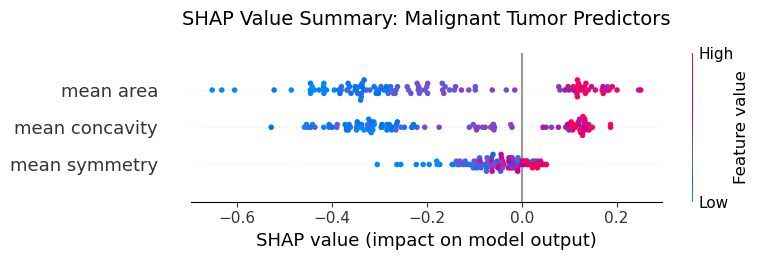

--- Gini Feature Importance ---


,Feature,Gini Importance
0,mean area,0.424090
1,mean concavity,0.411427
2,mean symmetry,0.164483


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap


#  데이터 로드 및 컬럼 선택 
cancer = load_breast_cancer()
features = ['mean area', 'mean concavity', 'mean symmetry']
full_df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df = full_df[features] 
y = np.where(cancer.target == 0, 1, 0) # 1: Malignant


X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42, stratify=y)

# XAI 분석용 앙상블 모델 재학습 
# (트리 기반 모델은 스케일링이 결과에 영향을 미치지 않으므로, 
# 시각화 시 원래의 물리적 수치를 확인하기 위해 스케일링 전 원본 데이터를 사용합니다)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight={0: 1, 1: 5})
rf_model.fit(X_train, y_train)

# 3. SHAP TreeExplainer 객체 생성 (게임 이론 기반 기여도 계산)
explainer = shap.TreeExplainer(rf_model)

# 악성 종양(1) 클래스에 대한 SHAP Value만 추출
# (버전에 따라 반환 형태가 다를 수 있으나, 일반적으로 인덱스 1이 악성 클래스
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values_mal = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_mal = shap_values[:, :, 1]
else:
    shap_values_mal = shap_values

#  SHAP Summary Plot 시각화
plt.figure(figsize=(10, 6))
plt.title('SHAP Value Summary: Malignant Tumor Predictors', fontsize=14, pad=20)
shap.summary_plot(shap_values_mal, X_test, plot_type="dot", show=False)
plt.savefig('../images/shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

#  전통적인 Gini Importance 수치 출력 (비교용)
importances = pd.DataFrame({
    'Feature': features,
    'Gini Importance': rf_model.feature_importances_
}).sort_values(by='Gini Importance', ascending=False)

print("--- Gini Feature Importance ---")
display(importances)